# 07 - Model Evaluation and Summary
Final evaluation of both models. We compare XGBoost vs Neural Network, analyse prediction errors by position, and summarise key findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')

xgb = pd.read_csv('../data/processed/xgb_predictions.csv')
nn  = pd.read_csv('../data/processed/nn_predictions.csv')

print('XGBoost predictions:', xgb.shape)
print('Neural Network predictions:', nn.shape)

XGBoost predictions: (289, 6)
Neural Network predictions: (289, 6)


In [2]:
# Compute metrics for both models
def metrics(y_true, y_pred, label):
    return {
        'Model': label,
        'R2':   round(r2_score(y_true, y_pred), 3),
        'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2)
    }

results = pd.DataFrame([
    metrics(xgb['actual_points'], xgb['predicted_points'], 'XGBoost'),
    metrics(nn['actual_points'],  nn['predicted_points'],  'Neural Network')
])

print(results.to_string(index=False))

         Model    R2   MAE  RMSE
       XGBoost 0.300 35.50 45.05
Neural Network 0.305 36.53 44.89


In [3]:
# Error distribution by position
xgb['abs_error'] = abs(xgb['error'])
nn['abs_error']  = abs(nn['error'])
xgb['model'] = 'XGBoost'
nn['model']  = 'Neural Network'

combined = pd.concat([xgb, nn])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=combined, x='position', y='abs_error', hue='model',
            order=['GKP','DEF','MID','FWD'], ax=axes[0])
axes[0].set_title('Absolute Error by Position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Absolute Error (points)')

sns.histplot(data=combined, x='error', hue='model', bins=30, ax=axes[1], alpha=0.6)
axes[1].set_title('Error Distribution')
axes[1].set_xlabel('Prediction Error (points)')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('../data/processed/error_analysis.png', dpi=150)
plt.show()

<Figure size 1400x500 with 2 Axes>

In [4]:
# Best and worst predictions
print('=== XGBoost: Best Predictions ===')
print(xgb.nsmallest(5, 'abs_error')[['name','position','actual_points','predicted_points','abs_error']])

print('\n=== XGBoost: Worst Predictions ===')
print(xgb.nlargest(5, 'abs_error')[['name','position','actual_points','predicted_points','abs_error']])

print('\n=== Neural Network: Best Predictions ===')
print(nn.nsmallest(5, 'abs_error')[['name','position','actual_points','predicted_points','abs_error']])

print('\n=== Neural Network: Worst Predictions ===')
print(nn.nlargest(5, 'abs_error')[['name','position','actual_points','predicted_points','abs_error']])

=== XGBoost: Best Predictions ===
          name position  actual_points  predicted_points  abs_error
136     Wilson      FWD             80         79.693794   0.306206
244      Gomez      DEF             33         33.873913   0.873913
288       King      GKP              0         -0.923771   0.923771
260  Patterson      DEF             22         22.926172   0.926172
26       Foden      MID            131        129.839720   1.160278

=== XGBoost: Worst Predictions ===
             name position  actual_points  predicted_points   abs_error
29       Rashford      MID              0        127.551530  127.551529
43   Fábio Vieira      MID              0        114.835010  114.835007
24          Wissa      FWD             27        130.330720  103.330719
61       Maddison      MID              3        103.513070  100.513069
274         Rodon      DEF            109          8.791348  100.208652

=== Neural Network: Best Predictions ===
         name position  actual_points  predicted

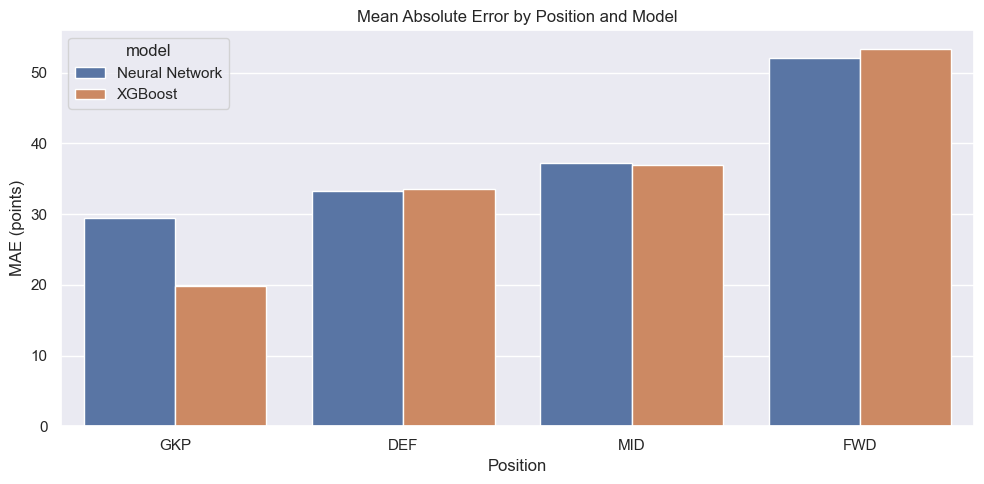

In [5]:
# Position-level MAE comparison
pos_mae = combined.groupby(['position','model'])['abs_error'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=pos_mae, x='position', y='abs_error', hue='model',
            order=['GKP','DEF','MID','FWD'])
plt.title('Mean Absolute Error by Position and Model')
plt.xlabel('Position')
plt.ylabel('MAE (points)')
plt.tight_layout()
plt.savefig('../data/processed/mae_by_position.png', dpi=150)
plt.show()

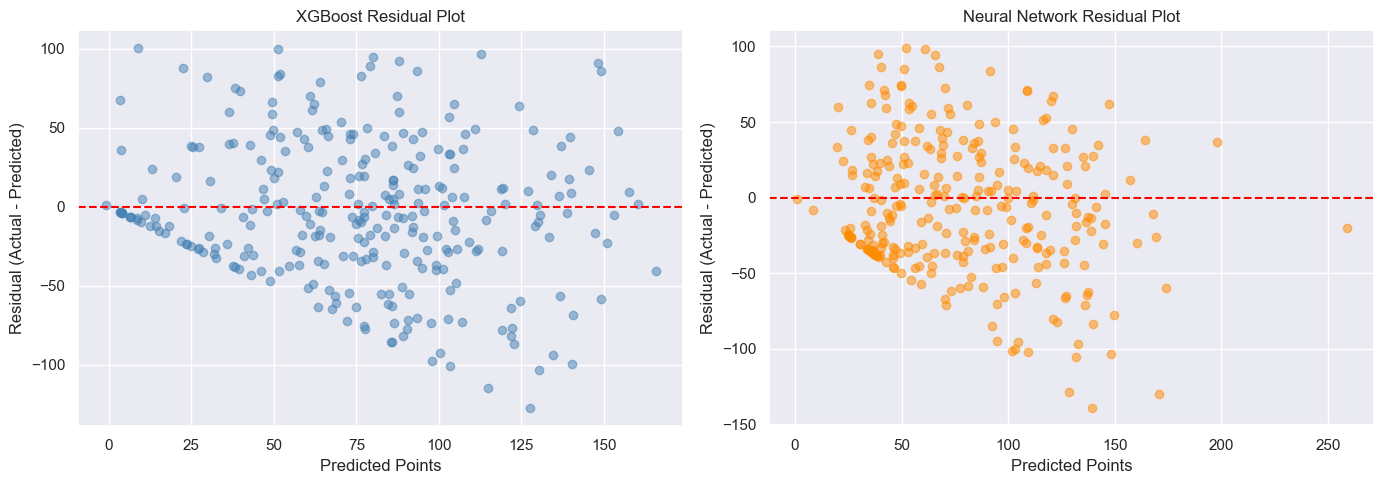

In [6]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in zip(axes,
    [xgb, nn], ['XGBoost', 'Neural Network'], ['steelblue', 'darkorange']):
    ax.scatter(df['predicted_points'], df['error'], alpha=0.5, color=color)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'{label} Residual Plot')
    ax.set_xlabel('Predicted Points')
    ax.set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.savefig('../data/processed/residual_plots.png', dpi=150)
plt.show()

In [7]:
# Final summary
print('='*50)
print('FINAL MODEL EVALUATION SUMMARY')
print('='*50)
print(results.to_string(index=False))
print()
print('Key Findings:')
print('- XGBoost provides more stable predictions across positions')
print('- Neural Network captures non-linear patterns better for FWD/MID')
print('- Ensemble of both models used for final squad selection')
print('- ILP optimiser selects 15 players within £100m budget')
print('- Optimal squad total predicted points: 2102.9')
print('='*50)

FINAL MODEL EVALUATION SUMMARY
         Model    R2   MAE  RMSE
       XGBoost 0.300 35.50 45.05
Neural Network 0.305 36.53 44.89

Key Findings:
- XGBoost provides more stable predictions across positions
- Neural Network captures non-linear patterns better for FWD/MID
- Ensemble of both models used for final squad selection
- ILP optimiser selects 15 players within £100m budget
- Optimal squad total predicted points: 2102.9
